In [ ]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

In [ ]:
!python ~/STEER/diffusers/exchange_scripts/generate_samples.py \
    --lam-start 0.85 --lam-end 1.15 --n-particles 4 \
    --tsr-path "images/tsr_tester" \
    --steer-path "images/steer_tester"

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

/n/netscratch/kempner_undergrads/Everyone/zwu/environments/stable_diff/lib/python3.10/site-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 8, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Computing real image features...


100%|██████████| 8/8 [00:08<00:00,  1.12s/it]


Real features computed from 950 images.



...

[False]  lam=0.950  FID=69.1676  CLIP=32.4001


CLIP lam=1.05: 100%|██████████| 950/950 [00:39<00:00, 24.19it/s]


[False]  lam=1.050  FID=67.8940  CLIP=32.5795


CLIP lam=1.15: 100%|██████████| 950/950 [00:42<00:00, 22.29it/s]


[False]  lam=1.150  FID=68.5308  CLIP=32.6485


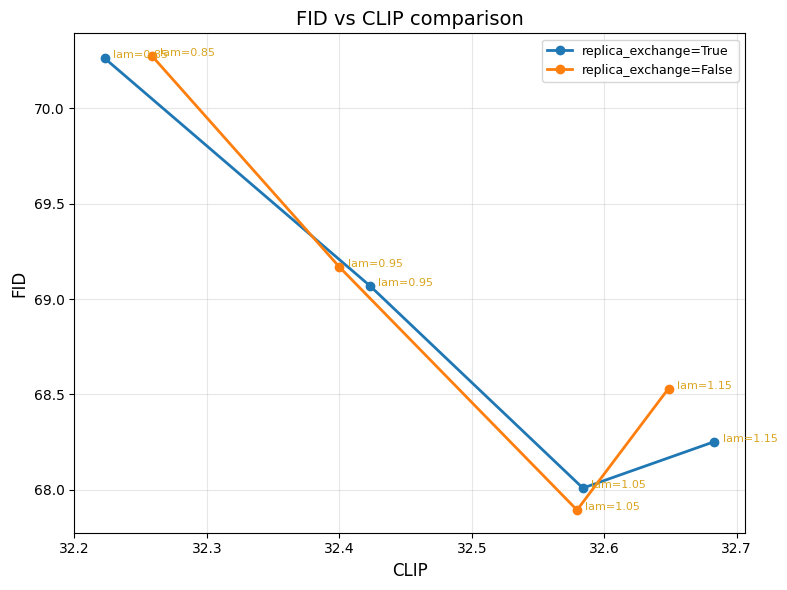

In [1]:
import sys
sys.path.append('~/STEER')  # or use os.path.expanduser('~/STEER')

import importlib.util
import os

path = os.path.expanduser('~/STEER/diffusers/exchange_scripts/fid.py')
spec = importlib.util.spec_from_file_location("generate_samples", path)
module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(module)

compute_sweep = module.compute_sweep

import os 
from pathlib import Path

tsr_results = compute_sweep(
    replica_exchanges=[True, False],
    device="cuda",
    target_indices=None,
    index_until=950,
    tsr_dir=Path("images/tsr"),
    pt_tsr_dir=Path("images/steer_flow"),        # fix kwarg name
    lam_values_ptsr=[0.85, 0.95, 1.05, 1.15],
    lam_values_tsr=[0.85, 0.95, 1.05, 1.15],
)